<a href="https://colab.research.google.com/github/NathanFairhurst/NathanFairhurst/blob/main/Paris_Olympic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applying Plotly and PySpark to Create Interactive Graphs and Analysis of The 2024 Paris Olympics Dataset

Before the notebook can be run, an API token needs to be uploaded to the notebook so it can access the dataset.

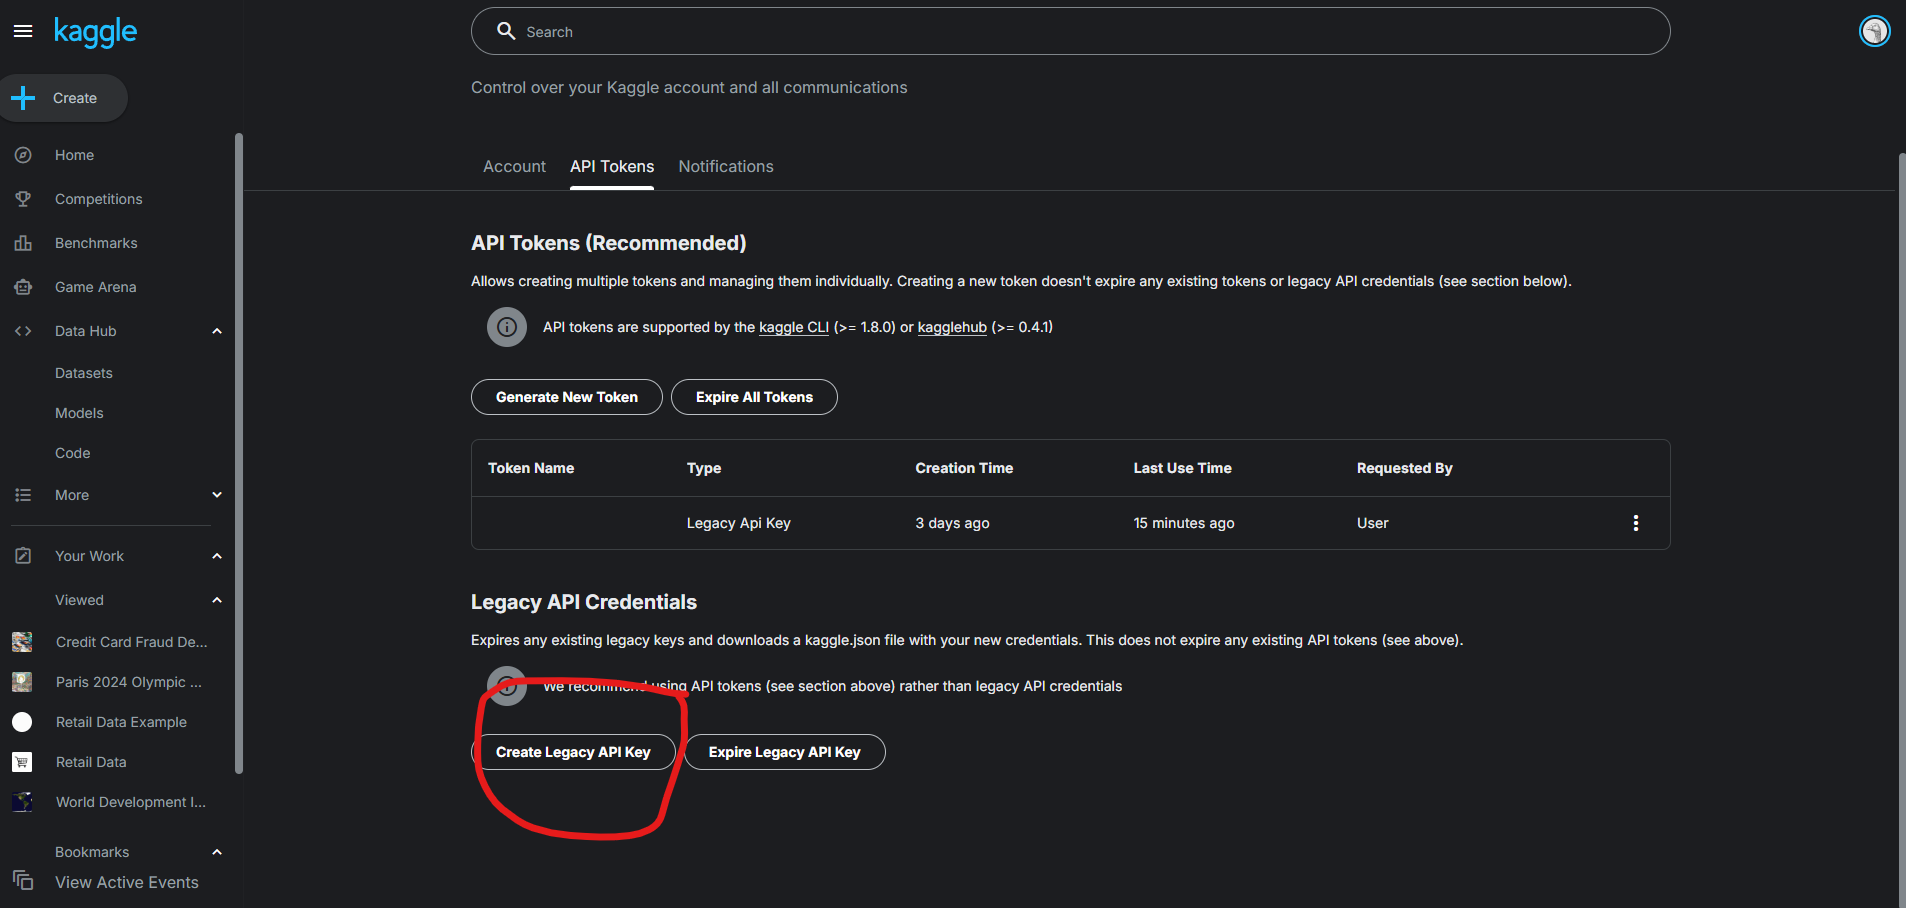

First, create an account on Kaggle if you haven't already and go to the settings, then API Tokens. Click on the Create Legacy API Key (circled in red) and a kaggle.json file should download. import the file in the colab notebook and this will allow you to access the Paris 2024 dataset.

In [1]:
from google.colab import files
files.upload()
# Run this cell and upload the kaggle.json file to the notebook

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nathanfair","key":"4a484fdab7d883ca22b407cd711bdbeb"}'}

In [2]:
!ls -lha kaggle.json
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!pwd
!chmod 600 ~/.kaggle/kaggle.json

-rw-r--r-- 1 root root 66 Aug 21 10:54 kaggle.json
/content


In [3]:
!kaggle datasets list # This is a check to see if Kaggle and the Colab notebook are joined

ref                                                                  title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
debayank2024/netflix-movies-and-series                               Netflix Movies and Series                      1400865  2026-07-27 09:40:46.527000           6633        159                1  
harshadapatil31/student-performance-and-study-habits-dataset         Student Performance & Study Habits Dataset       15035  2026-07-06 06:28:52.743000          13195        258                1  
srisyra02/spotify-music-artist-streaming-analytics                   Spotify Music Artist Streaming Analytics         23463  2026-08-07 03:20:03.313000           2355         37                1  
debayank2024/ho

In [4]:
!kaggle datasets download -d piterfm/paris-2024-olympic-summer-games # This cell downloads the Paris Olympics datasets to the notebook as a zipfile

Dataset URL: https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games
License(s): CC-BY-NC-SA-4.0
100% 2.95M/2.95M [00:00<00:00, 12.3MB/s]



In [5]:
!unzip '/content/paris-2024-olympic-summer-games.zip' # Unzip the Paris 2024 Olympics dataset

Archive:  /content/paris-2024-olympic-summer-games.zip
  inflating: athletes.csv            
  inflating: coaches.csv             
  inflating: events.csv              
  inflating: medallists.csv          
  inflating: medals.csv              
  inflating: medals_total.csv        
  inflating: nocs.csv                
  inflating: results/3x3 Basketball.csv  
  inflating: results/Archery.csv     
  inflating: results/Artistic Gymnastics.csv  
  inflating: results/Artistic Swimming.csv  
  inflating: results/Athletics.csv   
  inflating: results/Badminton.csv   
  inflating: results/Basketball.csv  
  inflating: results/Beach Volleyball.csv  
  inflating: results/Boxing.csv      
  inflating: results/Breaking.csv    
  inflating: results/Canoe Slalom.csv  
  inflating: results/Canoe Sprint.csv  
  inflating: results/Cycling BMX Freestyle.csv  
  inflating: results/Cycling BMX Racing.csv  
  inflating: results/Cycling Mountain Bike.csv  
  inflating: results/Cycling Road.csv  
  inflati

In [6]:
!pip install pyspark # Install PySpark to your Colab

In [7]:
import pyspark
spark = pyspark.sql.SparkSession(pyspark.SparkContext())
spark
import plotly.express as px
import pandas as pd
# These are all the libraries used in the notebook

# Medal Dataset
This dataset shows the total number of medals won by each country and it is divided into Gold, Silver and Bronze.

In [133]:
medals_total = pd.read_csv('/content/medals_total.csv')
medals_total.head() # .head() Shows the first 5 rows of data in the dataset

,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64


In [ ]:
fig = px.bar(medals_total, x = 'country', y = ['Gold Medal', 'Silver Medal', 'Bronze Medal'], color_discrete_sequence = ['Gold', 'Silver', '#CD7F32'], title = "# of Medals won by Country")
fig.update_layout(xaxis = {'categoryorder':'total descending'})
fig.show()

The bar chart above shows the total number of medals won by each country. Plotly graphs let you see the value of each variable by highlighting over each bar. USers can also zoom in and out as well as download the graph.

Some interesting data from the chart is that the United States won the most medals overall with 126 yet were tied with China for the most Gold Medals with 40 each. By zooming in to the end of the chart, we can see that 15 countries earned only 1 medal (Dominica, Pakistan, Cyprus, Fiji, Jordan, Mongolia, Panama, Cabo Verde, Cote d'Ivoire, EOR (Refugee Olympic Team), Peru, Qatar, Singapore, Slovakia and Zambia).

# Coaches Dataset

Coaches.csv shows a list of all the coaches who were at the Olympics. Data includes their name, country, disciplines, events (Team, Men, Women or Not Applicable) and Date of Birth.

In [ ]:
coaches_df = pd.read_csv('/content/coaches.csv')
coaches_df.head(25)

,code,current,name,gender,function,category,country_code,country,country_long,disciplines,events,birth_date
0,1533246,True,PEDRERO Ofelia,Female,Coach,C,MEX,Mexico,Mexico,Artistic Swimming,Team,1988-03-28
1,1535775,True,RADHI SHENAISHIL,Male,Head Coach,C,IRQ,Iraq,Iraq,Football,Men,1965-07-01
2,1536055,True,AFLAKIKHAMSEH Majid,Male,Coach,C,IRI,IR Iran,Islamic Republic of Iran,Taekwondo,NaN,1973-08-26
3,1536059,True,YOUSEFY Mehrdad,Male,Coach,C,IRI,IR Iran,Islamic Republic of Iran,Taekwondo,NaN,1972-06-12
4,1536060,True,MADDAH Minoo,Female,Coach,C,IRI,IR Iran,Islamic Republic of Iran,Taekwondo,NaN,1976-05-17
5,1536328,True,LOFTUS Adriana,Female,Coach,C,MEX,Mexico,Mexico,Artistic Swimming,Team,1958-06-28
6,1538313,True,FERRARA Fernando,Male,Head Coach,C,ARG,Argentina,Argentina,Hockey,NaN,1968-07-24
7,1538315,True,GULLA Alejandra,Female,Assistant Coach,C,ARG,Argentina,Argentina,Hockey,Women,1977-07-04
8,1538317,True,CAPURRO Santiago,Male,Assistant Coach,C,ARG,Argentina,Argentina,Hockey,NaN,1975-04-08
9,1538745,True,RONCONI Mariano,Male,Head Coach,C,ARG,Argentina,Argentina,Hockey,NaN,NaN


In [ ]:
spark.read.csv('/content/coaches.csv', header = True, inferSchema = True).createOrReplaceTempView('coaches') # This will change the coaches.csv file into temporary table so PySpark can be used to write queries

In [ ]:
spark.sql('SELECT * FROM coaches') # This selects all the columns in the coaches dataset and shows the data type of each

DataFrame[code: int, current: boolean, name: string, gender: string, function: string, category: string, country_code: string, country: string, country_long: string, disciplines: string, events: string, birth_date: date]

In [ ]:
spark.sql('SELECT * FROM coaches').show() # Shows the all the data in the top 20 rows of the coaches dataset

+-------+-------+--------------------+------+---------------+--------+------------+---------+--------------------+-------------------+------+----------+
|   code|current|                name|gender|       function|category|country_code|  country|        country_long|        disciplines|events|birth_date|
+-------+-------+--------------------+------+---------------+--------+------------+---------+--------------------+-------------------+------+----------+
|1533246|   true|      PEDRERO Ofelia|Female|          Coach|       C|         MEX|   Mexico|              Mexico|  Artistic Swimming|  Team|1988-03-28|
|1535775|   true|    RADHI SHENAISHIL|  Male|     Head Coach|       C|         IRQ|     Iraq|                Iraq|           Football|   Men|1965-07-01|
|1536055|   true| AFLAKIKHAMSEH Majid|  Male|          Coach|       C|         IRI|  IR Iran|Islamic Republic ...|          Taekwondo|  NULL|1973-08-26|
|1536059|   true|     YOUSEFY Mehrdad|  Male|          Coach|       C|         IRI

In [ ]:
pd_coach_query = spark.sql('SELECT country, COUNT(country) AS COUNT FROM coaches GROUP BY country ORDER BY COUNT DESC').toPandas()
'''
Selects the only the columns country and the count of coaches from each country.
The data is then put in descending order.
'''
pd_coach_query.head(25) # Prints the first 25 rows of data

,country,COUNT
0,Spain,68
1,United States,56
2,France,55
3,China,45
4,Japan,43
5,Australia,40
6,Germany,37
7,Brazil,35
8,Canada,34
9,Great Britain,32


The table above shows that Spain brought the most coaches with them with 68, followed by the United States with 56.

In [ ]:
fig = px.bar(pd_coach_query, x = 'country', y = 'COUNT', title = '# of Coaches per Country')
fig.update_layout(xaxis = {'categoryorder':'total descending'})
fig.show()

The bar chart above shows the total number of coaches per country. This is a better way of interpreting the data since Plotly lets us interact with the chart.

# Athletes Dataset

In [ ]:
athletes_df = pd.read_csv('/content/athletes.csv')
athletes_df.head(25)

,code,current,name,name_short,name_tv,gender,function,country_code,country,country_long,...,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Father, Gevorg Aleksanyan","Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN
1,1532873,True,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,NaN,NaN,NaN,NaN,"""To become a good athlete, you first have to b...","Uncle, Roman Amoyan (wrestling), 2008 Olympic ...",NaN,NaN
2,1532874,True,GALSTYAN Slavik,GALSTYAN S,Slavik GALSTYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,Personal: Martin Alekhanyan (ARM).<br>National...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1532944,True,HARUTYUNYAN Arsen,HARUTYUNYAN A,Arsen HARUTYUNYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Diana (married October 2022). Daughter, ...",Armenian,National: Habetnak Kurghinyan,While doing karate he noticed wrestlers traini...,"Wrestler Armen Nazaryan (ARM, BUL), two-time O...",NaN,"“Nothing is impossible, set goals in front of ...",NaN,NaN,NaN
4,1532945,True,TEVANYAN Vazgen,TEVANYAN V,Vazgen TEVANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Sona (married November 2023)","Armenian, Russian",National: Habetnak Kurghinyan (ARM),“My family did not like wrestling very much. A...,NaN,NaN,NaN,NaN,NaN,NaN
5,1532951,True,ARENAS Lorena,ARENAS L,Lorena ARENAS,Female,Athlete,COL,Colombia,Colombia,...,"Father, Jose Otoniel. Mother, Maria Rudy. Has ...",Spanish,Personal: Brent Vallance (AUS),NaN,"Race walker Luis Fernando Lopez (COL), four-ti...",NaN,NaN,NaN,In competition she wears a ring or earrings he...,NaN
6,1533112,True,McKENZIE Ashley,McKENZIE A,Ashley McKENZIE,Male,Athlete,JAM,Jamaica,Jamaica,...,"One daughter, Lana-Rose, who lives in France",English,Personal and National: Luke Preston (GBR),"""I was thrown over [an argument about] a Pokem...","Boxer Muhammad Ali, born Cassius Clay (USA), f...","""My coach Luke Preston. We've been a team for ...",NaN,NaN,NaN,NaN
7,1533136,True,BASS BITTAYE Gina Mariam,BASS BITTAYE GM,Gina Mariam BASS BITTAYE,Female,Athlete,GAM,Gambia,Gambia,...,"Husband, Mustapha Bittaye - physical education...","English, French",Personal: Christophe Belliard (FRA),“I started running when I was in primary schoo...,"Sprinter Shelly-Ann Fraser-Pryce (JAM), three ...",NaN,"""If you believe in yourself, never be discoura...",NaN,NaN,NaN
8,1533176,True,CAMARA Ebrahima,CAMARA E,Ebrahima CAMARA,Male,Athlete,GAM,Gambia,Gambia,...,Married. One daughter. Has three brothers,"Arabic, English, French, Mandinka, Wolof",Personal: Christophe Belliard (FRA),"""I love running and I was fast a child."" (Athl...","Sprinter Gina Mariam Bass Bittaye (GAM), two-t...","Momodou Lamin Kujabi, a former international a...","""What does not kill you makes you stronger."" (...",NaN,NaN,NaN
9,1533188,True,RUEDA SANTOS Lizeth,RUEDA SANTOS L,Lizeth RUEDA SANTOS,Female,Athlete,MEX,Mexico,Mexico,...,NaN,Spanish,Personal: Eugenio Chimal (MEX),Was a competitive swimmer from age 12 and went...,NaN,NaN,NaN,NaN,NaN,Competed in marathon swimming at London 2012. ...


The athletes dataset is quite large with over 36 columns of data. A lot of this data is unnecessary such as the hero, influence or ritual columns since the data is difficult to show in a graph and contains missing (Null) values.

In [ ]:
spark.read.csv('athletes.csv', header = True, inferSchema = True).createOrReplaceTempView('athletes') # Like before, we have created a temporary table so PySpark queries can be written
spark.sql('SELECT * FROM athletes') # Shows all the data types from the athletes dataset. A lot of the data is type string (text) making it difficult to quantify outside of columns such as country, gender, discipline, events

DataFrame[code: int, current: boolean, name: string, name_short: string, name_tv: string, gender: string, function: string, country_code: string, country: string, country_long: string, nationality: string, nationality_long: string, nationality_code: string, height: double, weight: double, disciplines: string, events: string, birth_date: string, birth_place: string, birth_country: string, residence_place: string, residence_country: string, nickname: string, hobbies: string, occupation: string, education: string, family: string, lang: string, coach: string, reason: string, hero: string, influence: string, philosophy: string, sporting_relatives: string, ritual: string, other_sports: string]

In [ ]:
spark.sql('SELECT * FROM athletes').show() # Shows all the columns and first 20 rows of the athletes dataset

+-------+-------+--------------------+---------------+--------------------+------+--------+------------+--------+------------+-----------+----------------+----------------+------+------+--------------------+--------------------+--------------------+-------------------+-------------+-------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|   code|current|                name|     name_short|             name_tv|gender|function|country_code| country|country_long|nationality|nationality_long|nationality_code|height|weight|         disciplines|              events|          birth_date|        birth_place|birth_country|    residence_place|residence_country|            nickname|             hobbies|          occupation|

In [ ]:
spark.sql('SELECT code, name, gender, country_code, country, nationality, disciplines FROM athletes ORDER BY country, disciplines').show(25)
# Using the SQL query, I have selected all data I think is important
# Removing unnecessary data makes reading tables much easier

+-------+--------------------+------+------------+-------+------------------+----------------+
|   code|                name|gender|country_code|country|       nationality|     disciplines|
+-------+--------------------+------+------------+-------+------------------+----------------+
|1979109|  KOROVASHKOV Alexey|  Male|         AIN|    AIN|Russian Federation|['Canoe Sprint']|
|1941072|  KRAVETS Uladzislau|  Male|         AIN|    AIN|           Belarus|['Canoe Sprint']|
|1979110|       PETROV Zakhar|  Male|         AIN|    AIN|Russian Federation|['Canoe Sprint']|
|1945968|    TRUSHKINA Yuliya|Female|         AIN|    AIN|           Belarus|['Canoe Sprint']|
|1979114|    ROMASENKO Olesia|Female|         AIN|    AIN|Russian Federation|['Canoe Sprint']|
|1549335|       TSERAKH Hanna|Female|         AIN|    AIN|           Belarus|['Cycling Road']|
|1973314|      DRONOVA Tamara|Female|         AIN|    AIN|Russian Federation|['Cycling Road']|
|1979019|    IVANCHENKO Alena|Female|         AIN|

In [ ]:
pd_athletes_query = spark.sql('''SELECT first(country) AS country, first(disciplines) as disciplines,
COUNT(*) AS COUNT FROM athletes GROUP BY country, disciplines ORDER BY country, disciplines, COUNT DESC''').toPandas()

'''
This query selects the country and discplines that each country participated in shows the number of athletes who competed.
The table is then converted back to Pandas so it can be used in Plotly. The resutling table, order by the country and then
discipline in alphabetical order, shows Individual Neutral Athletes or AIN. These athletes are mostly from Belarus and Russia.
'''

pd_athletes_query.head(25)

,country,disciplines,COUNT
0,AIN,['Canoe Sprint'],5
1,AIN,['Cycling Road'],4
2,AIN,['Rowing'],2
3,AIN,['Shooting'],2
4,AIN,['Swimming'],4
5,AIN,['Taekwondo'],1
6,AIN,['Tennis'],7
7,AIN,['Trampoline Gymnastics'],3
8,AIN,['Weightlifting'],2
9,AIN,['Wrestling'],2


In [ ]:
fig = px.bar(pd_athletes_query, x = 'country', y = 'COUNT', color = 'disciplines', title = '# of Athletes From Each Country Per Discipline')
fig.update_layout(xaxis = {'categoryorder':'total descending'})
fig.show()


The table above shows the total number of athletes from each country and the disciplines each athlete participated in. The table is however difficult to read due to the many disciplines at the Olympics.

In [ ]:
athletes_df['disciplines'].value_counts().head(10) # This shows the top 10 disciplines with the vast majority being placed in athletics

,count
disciplines,
['Athletics'],2018
['Swimming'],836
['Football'],553
['Rowing'],493
['Hockey'],415
['Handball'],386
['Judo'],378
['Shooting'],342
['Sailing'],330


In [ ]:
top_disciplines_actual_format = athletes_df['disciplines'].value_counts().head(5).index.tolist()
# This top_disciplines_actual_format variable shows the top 5 disciplines (Athletics, Swimming, Football, Rowing, Hockey) and the count of each per country
pd_athletes_query = pd_athletes_query.loc[pd_athletes_query['disciplines'].isin(top_disciplines_actual_format)]
display(pd_athletes_query.head())

,country,disciplines,COUNT
2,AIN,['Rowing'],2
4,AIN,['Swimming'],4
10,Afghanistan,['Athletics'],2
13,Afghanistan,['Swimming'],1
14,Albania,['Athletics'],2


In [19]:
fig = px.bar(pd_athletes_query, x = 'country', y = 'COUNT', color = 'disciplines', title = '# of athletes from each country per top 5 disciplines')
fig.update_layout(xaxis = {'categoryorder':'total descending'})
fig.show()

NameError: name 'pd_athletes_query' is not defined

The new bar chart that show the total number of athletes for the top 5 disciplines. This table is more readable than the previous since we are not showing every form of discipline.

# Teams Dataset

In [ ]:
teams_df = pd.read_csv('/content/teams.csv')
teams_df.head(5)

,code,current,team,team_gender,country_code,country,country_long,discipline,disciplines_code,events,athletes,coaches,athletes_codes,num_athletes,coaches_codes,num_coaches
0,ARCMTEAM3---CHN01,True,People's Republic of China,M,CHN,China,People's Republic of China,Archery,ARC,Men's Team,"['KAO Wenchao', 'LI Zhongyuan', 'WANG Yan']",NaN,"['1913366', '1913367', '1913369']",3.0,NaN,NaN
1,ARCMTEAM3---COL01,True,Colombia,M,COL,Colombia,Colombia,Archery,ARC,Men's Team,"['ARCILA Santiago', 'ENRIQUEZ Jorge', 'HERNAND...",NaN,"['1935642', '1543412', '1935644']",3.0,NaN,NaN
2,ARCMTEAM3---FRA01,True,France,M,FRA,France,France,Archery,ARC,Men's Team,"['ADDIS Baptiste', 'CHIRAULT Thomas', 'VALLADO...",NaN,"['1541270', '1541272', '1541275']",3.0,NaN,NaN
3,ARCMTEAM3---GBR01,True,Great Britain,M,GBR,Great Britain,Great Britain,Archery,ARC,Men's Team,"['HALL Conor', 'HALL Tom', 'WISE Alex']",NaN,"['1560988', '1560989', '1561003']",3.0,NaN,NaN
4,ARCMTEAM3---IND01,True,India,M,IND,India,India,Archery,ARC,Men's Team,"['BOMMADEVARA Dhiraj', 'JADHAV Pravin Ramesh',...",NaN,"['1546108', '1546112', '1546110']",3.0,NaN,NaN


### Gender Distribution Per Discipline

To visualize the gender distribution across different disciplines, we'll first clean the `disciplines` column in the `athletes_df` DataFrame, which currently contains string representations of lists. We'll then group the data by discipline and gender to count athletes and create individual pie charts for each discipline.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [ ]:
events_df = pd.read_csv('/content/events.csv')
events_df.head(5)

,event,tag,sport,sport_code,sport_url
0,Men's Individual,archery,Archery,ARC,https://olympics.com/en/paris-2024/sports/archery
1,Women's Individual,archery,Archery,ARC,https://olympics.com/en/paris-2024/sports/archery
2,Men's Team,archery,Archery,ARC,https://olympics.com/en/paris-2024/sports/archery
3,Women's Team,archery,Archery,ARC,https://olympics.com/en/paris-2024/sports/archery
4,Mixed Team,archery,Archery,ARC,https://olympics.com/en/paris-2024/sports/archery


In [ ]:
print(events_df['sport'].value_counts()) # Shows each sport at the Olympics and the count of each

sport
Athletics                48
Swimming                 35
Wrestling                18
Shooting                 15
Judo                     15
Artistic Gymnastics      14
Rowing                   14
Boxing                   13
Cycling Track            12
Fencing                  12
Sailing                  10
Canoe Sprint             10
Weightlifting            10
Taekwondo                 8
Diving                    8
Canoe Slalom              6
Equestrian                6
Table Tennis              5
Tennis                    5
Badminton                 5
Archery                   5
Sport Climbing            4
Skateboarding             4
Cycling Road              4
Triathlon                 3
Basketball                2
Artistic Swimming         2
3x3 Basketball            2
Beach Volleyball          2
Cycling BMX Freestyle     2
Breaking                  2
Rhythmic Gymnastics       2
Hockey                    2
Golf                      2
Handball                  2
Cycling BMX Ra

In [ ]:
print(len(events_df['sport'].value_counts())) # Shows the total number of sports at the Paris Olympics

45


In [ ]:
specs = [[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}]] * 15 # This shows the layout for the pie charts
specs

[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
 [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]]

In [ ]:
import ast # Import Abstract Syntax Tree or AST

# Function to safely parse the discipline string and extract the first discipline
def get_primary_discipline(discipline_str):
    try:
        discipline_list = ast.literal_eval(discipline_str)
        if isinstance(discipline_list, list) and len(discipline_list) > 0:
            return discipline_list[0]
    except (ValueError, SyntaxError):
        pass  # Handle cases where the string isn't a valid list representation
    return None

# Apply the function to create a new 'primary_discipline' column
athletes_df['primary_discipline'] = athletes_df['disciplines'].apply(get_primary_discipline)

# Drop rows where primary_discipline could not be extracted
athletes_df_cleaned = athletes_df.dropna(subset=['primary_discipline']).copy()

# Calculate gender distribution per primary discipline
gender_counts_per_discipline = athletes_df_cleaned.groupby(['primary_discipline', 'gender']).size().unstack(fill_value=0)
display(gender_counts_per_discipline.head())

gender,Female,Male
primary_discipline,,
3x3 Basketball,33,32
Archery,64,64
Artistic Gymnastics,94,96
Artistic Swimming,106,0
Athletics,982,1036


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

unique_disciplines_for_plot = gender_counts_per_discipline.index.tolist()

num_disciplines = len(unique_disciplines_for_plot)
cols = 3 # Number of columns for the subplot grid
num_rows = (num_disciplines + cols - 1) // cols

specs = [[{'type':'domain'}] * cols for _ in range(num_rows)]
fig = make_subplots(
    rows = num_rows,
    cols = cols,
    subplot_titles = unique_disciplines_for_plot,
    specs = specs
)

k = 0
for discipline in unique_disciplines_for_plot:
    row_data = gender_counts_per_discipline.loc[discipline]

    labels = []
    values = []

    # Check for 'Male' count
    if 'Male' in row_data.index and row_data['Male'] > 0:
        labels.append('Male Athletes')
        values.append(row_data['Male'])

    # Check for 'Female' count
    if 'Female' in row_data.index and row_data['Female'] > 0:
        labels.append('Female Athletes')
        values.append(row_data['Female'])

    row_idx = (k // cols) + 1
    col_idx = (k % cols) + 1

    fig.add_trace(go.Pie(labels=labels, values=values, name=discipline),
                  row=row_idx, col=col_idx)
    k += 1

fig.update_layout(
    title_text="Gender Distribution Across Olympic Disciplines",
    showlegend=False,
    height=400 * num_rows,
    width=1200
)
fig.update_traces(textposition='inside', textinfo='percent+label')

fig.show()

Shows a pie chart for each sport at the Olympics and the percentage of male and female athletes in each sport. Sports like Artistic Swimming and Rhythmic Gymnastics had all female athletes while most sports excluding wrestling, football and some water sports have a large percentage of male athletes than female.

# Medallists Dataset

In [14]:
medallists_df = pd.read_csv('/content/medallists.csv')
medallists_df.head(5) # .head() Shows the first 5 rows of data in the dataset

,medal_date,medal_type,medal_code,name,gender,country_code,country,country_long,nationality_code,nationality,...,team,team_gender,discipline,event,event_type,url_event,birth_date,code_athlete,code_team,is_medallist
0,2024-07-27,Gold Medal,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,2000-01-25,1903136,NaN,True
1,2024-07-27,Silver Medal,2.0,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1996-07-25,1923520,NaN,True
2,2024-07-27,Bronze Medal,3.0,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1994-09-15,1903147,NaN,True
3,2024-07-27,Gold Medal,1.0,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1992-07-07,1940173,NaN,True
4,2024-07-27,Silver Medal,2.0,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1998-11-14,1912525,NaN,True


In [142]:
spark.read.csv('medallists.csv', header = True, inferSchema = True).createOrReplaceTempView('medallists')

In [143]:
medallists_df_query = spark.sql('SELECT * FROM medallists;')
medallists_df_query.show()

+----------+------------+----------+--------------------+------+------------+----------------+--------------------+----------------+----------------+--------------------+----+-----------+------------+--------------------+----------+--------------------+----------+------------+---------+------------+
|medal_date|  medal_type|medal_code|                name|gender|country_code|         country|        country_long|nationality_code|     nationality|    nationality_long|team|team_gender|  discipline|               event|event_type|           url_event|birth_date|code_athlete|code_team|is_medallist|
+----------+------------+----------+--------------------+------+------------+----------------+--------------------+----------------+----------------+--------------------+----+-----------+------------+--------------------+----------+--------------------+----------+------------+---------+------------+
|2024-07-27|  Gold Medal|       1.0|     EVENEPOEL Remco|  Male|         BEL|         Belgium|   

In [165]:
medallists_df_query = spark.sql('SELECT country, discipline, medal_code, medal_type, COUNT(*) AS medal_count FROM medallists GROUP BY country, discipline, medal_code, medal_type ORDER BY discipline ASC').toPandas()
medallists_df_query.head()

,country,discipline,medal_code,medal_type,medal_count
0,Germany,3x3 Basketball,1.0,Gold Medal,4
1,France,3x3 Basketball,2.0,Silver Medal,4
2,Lithuania,3x3 Basketball,3.0,Bronze Medal,4
3,Netherlands,3x3 Basketball,1.0,Gold Medal,4
4,United States,3x3 Basketball,3.0,Bronze Medal,4


In [175]:
fig = px.bar(medallists_df_query, x = 'country', y = 'medal_count', color = 'discipline', title = 'Medals Won by Each Country Per Discipline')
fig.update_layout(xaxis = {'categoryorder':'total descending'},  xaxis_title = "Country")
fig.update_traces(marker_line_width = 0)
fig.show()

The chart above shows the total number of medals won for each country per disdiscipline. From the chart, we can see that the United States were standouts in disciplines such as swimming (where they won 70 medals) and athletics (where they won 60) and a standout being Australia being the country with the second highest amount of medals in swimming with 51.

While the chart looks chaotic, I think it gives us good information what disciplines countries exceled or struggled in. For example Fiji only won medals in rugby, their national sport similarly, the majority of Brazil and Spain's medals came through football, their national sport.